# Cài đặt môi trường

In [1]:
!pip install -q monai[all]  
!pip install -q nibabel      
!pip install -q trimesh fast_simplification

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 23.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 28.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 67.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 34.4 MB/s eta 0:00:00:00:0100:01
   ━

In [2]:
import os
os.environ["MONAI_USE_CUPY"] = "0" 

import gc
import glob
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose,
    RandCropByPosNegLabeld,
    RandRotate90d,
    RandFlipd,
    RandGaussianNoised,
    RandShiftIntensityd,
    RandScaleIntensityd,
)
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.networks.utils import one_hot
from scipy.ndimage import binary_erosion
from sklearn.model_selection import train_test_split

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-09 16:48:19.454349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778345299.638895      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778345299.693410      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778345300.123441      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778345300.123479      57 computation_placer.cc:1

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
import os

base = "/kaggle/input/notebooks/khoayakult/model-ba-net/preprocessed_banet"

print("Images:", len(os.listdir(os.path.join(base, "images"))))
print("Labels:", len(os.listdir(os.path.join(base, "labels"))))

Images: 163
Labels: 163


In [4]:
# SAVE_DIR = "/kaggle/working/preprocessed_banet"
# DATA_ROOT = "/kaggle/input/datasets/xxxxxx123232/kits23-part1"

In [5]:
# # Tạo thư mục lưu trữ
# os.makedirs(os.path.join(SAVE_DIR, "images"), exist_ok=True)
# os.makedirs(os.path.join(SAVE_DIR, "labels"), exist_ok=True)

In [6]:
# # BA-Net spacing chuẩn
# TARGET_SPACING = (1.5, 1.5, 2.0)

# # HU window cho kidney (theo paper KiTS)
# HU_MIN, HU_MAX = -100, 200

# Data preprocessing

In [7]:
# train_pipeline = Compose([
#     LoadImaged(keys=["image", "label"], image_only=False),
#     EnsureChannelFirstd(keys=["image", "label"]),
    
#     Orientationd(
#         keys=["image", "label"], 
#         axcodes="RAS",
#         labels=(("L", "R"), ("P", "A"), ("I", "S"))  # Explicitly set labels
#     ),
    
#     Spacingd(
#         keys=["image", "label"],
#         pixdim=TARGET_SPACING,
#         mode=("bilinear", "nearest"),
#     ),
    
#     ScaleIntensityRanged(
#         keys=["image"],
#         a_min=HU_MIN,
#         a_max=HU_MAX,
#         b_min=0.0,
#         b_max=1.0,
#         clip=True,
#     ),
    
#     CropForegroundd(
#         keys=["image", "label"],
#         source_key="image",
#         margin=5,
#     ),
    
#     ToTensord(keys=["image", "label"]),
# ])

In [8]:
# inference_pipeline = Compose([
#     LoadImaged(keys=["image"], image_only=False),
#     EnsureChannelFirstd(keys=["image"]),
    
#     Orientationd(
#         keys=["image"], 
#         axcodes="RAS",
#         labels=(("L", "R"), ("P", "A"), ("I", "S"))
#     ),
    
#     Spacingd(
#         keys=["image"],
#         pixdim=TARGET_SPACING,
#         mode="bilinear",
#     ),
    
#     ScaleIntensityRanged(
#         keys=["image"],
#         a_min=HU_MIN,
#         a_max=HU_MAX,
#         b_min=0.0,
#         b_max=1.0,
#         clip=True,
#     ),
    
#     CropForegroundd(
#         keys=["image"],
#         source_key="image",
#         margin=5,
#     ),
    
#     ToTensord(keys=["image"]),
# ])

In [9]:
# def validate_label(label_tensor):
#     """Kiểm tra label có hợp lệ không"""
#     unique_values = torch.unique(label_tensor)
#     valid_labels = {0, 1, 2, 3}  # KiTS23: background, kidney, mass, cyst
    
#     if not all(val.item() in valid_labels for val in unique_values):
#         print(f"Label có giá trị không hợp lệ: {unique_values.tolist()}")
#         return False
#     return True

In [10]:
# def process_case(folder, pipeline, has_label=True):
#     """Xử lý một case"""
#     case_id = os.path.basename(folder)
#     img_path = os.path.join(folder, "imaging.nii")
#     lbl_path = os.path.join(folder, "segmentation.nii")
    
#     if not os.path.exists(img_path):
#         print(f"❌ {case_id}: Không tìm thấy imaging.nii")
#         return False
    
#     if has_label and not os.path.exists(lbl_path):
#         print(f"⚠️ {case_id}: Không có label → inference mode")
#         has_label = False
    
#     try:
#         # Chọn pipeline
#         if has_label:
#             data_dict = {"image": img_path, "label": lbl_path}
#             processed = pipeline(data_dict)
#         else:
#             data_dict = {"image": img_path}
#             processed = inference_pipeline(data_dict)
        
#         # Lấy image
#         img_tensor = processed["image"].to(torch.float16)
#         original_shape = img_tensor.shape
        
#         # Lưu image
#         torch.save(img_tensor, os.path.join(SAVE_DIR, "images", f"{case_id}.pt"))
        
#         # Xử lý label
#         if has_label:
#             lbl_tensor = processed["label"].to(torch.uint8)
#             validate_label(lbl_tensor)
#             torch.save(lbl_tensor, os.path.join(SAVE_DIR, "labels", f"{case_id}.pt"))
#             print(f"✅ {case_id} | Shape: {original_shape} | Labels: {torch.unique(lbl_tensor).tolist()}")
#         else:
#             print(f"✅ {case_id} | Shape: {original_shape} | Inference only")
        
#         return True
        
#     except Exception as e:
#         print(f"❌ Lỗi tại {case_id}: {str(e)}")
#         import traceback
#         traceback.print_exc()
#         return False
    
#     finally:
#         # Memory cleanup
#         for var in ['data_dict', 'processed', 'img_tensor', 'lbl_tensor']:
#             if var in locals():
#                 del locals()[var]
#         gc.collect()
#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()

In [11]:
# if __name__ == "__main__":
#     patient_folders = sorted(glob.glob(os.path.join(DATA_ROOT, "case_*")))
    
#     print("=" * 60)
#     print("🚀 BA-NET PREPROCESSING PIPELINE")
#     print(f"📁 Data: {DATA_ROOT}")
#     print(f"💾 Output: {SAVE_DIR}")
#     print(f"📏 Spacing: {TARGET_SPACING}")
#     print(f"🔬 HU window: [{HU_MIN}, {HU_MAX}]")
#     print(f"🔍 Cases: {len(patient_folders)}")
#     print("=" * 60)
    
#     success = 0
#     failed = 0
    
#     for idx, folder in enumerate(patient_folders, 1):
#         print(f"\n[{idx}/{len(patient_folders)}] {os.path.basename(folder)}...")
#         if process_case(folder, train_pipeline, has_label=True):
#             success += 1
#         else:
#             failed += 1
    
#     print("\n" + "=" * 60)
#     print("🎉 HOÀN THÀNH!")
#     print(f"✅ Thành công: {success}")
#     print(f"❌ Thất bại: {failed}")
#     print(f"📊 Tỷ lệ: {success/(success+failed)*100:.1f}%")
#     print("=" * 60)

# Prepare

In [12]:
# ============================================================
# GLOBAL CONFIG - Adjust these before running
# ============================================================
CFG = {
    # Paths
    "data_dir": "/kaggle/input/notebooks/khoayakult/model-ba-net/preprocessed_banet",  # Where .pt files are stored
    "output_dir": "/kaggle/working/banet_output",

    # Dataset split ratios (train/val/test)
    "train_ratio": 0.70,
    "val_ratio":   0.15,
    "test_ratio":  0.15,
    "random_seed": 42,

    # Patch & Sampling
    "patch_size": (64, 64, 64),   # Increase to (128,128,128) if VRAM >= 20GB
    "num_patches_per_sample": 4,  # Patches cropped per patient per iteration
    "pos_neg_ratio": 1,           # 1:1 positive:negative patch ratio

    # Model
    "num_classes": 4,             # 0=bg, 1=kidney, 2=mass, 3=cyst
    "in_channels": 1,
    "base_features": 16,          # Reduce to 16 if OOM
    "boundary_weight": 0.4,       # Weight for boundary loss term

    # Training
    "epochs": 300,
    "batch_size": 2,              # Effective: batch_size * num_patches_per_sample patches
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "lr_warmup_epochs": 10,
    "num_workers": 2,
    "val_every": 5,               # Validate every N epochs
    "save_best_metric": "dice_mean",

    # Mixed precision
    "use_amp": True,
}

os.makedirs(CFG["output_dir"], exist_ok=True)
os.makedirs(os.path.join(CFG["output_dir"], "checkpoints"), exist_ok=True)

# Reproducibility
random.seed(CFG["random_seed"])
np.random.seed(CFG["random_seed"])
torch.manual_seed(CFG["random_seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG["random_seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [13]:
def build_splits(data_dir, train_ratio, val_ratio, seed):
    """
    Discover all preprocessed cases and split into train/val/test.
    Returns three lists of dicts: [{image: path, label: path}, ...]
    """
    image_paths = sorted(glob.glob(os.path.join(data_dir, "images", "*.pt")))
    label_paths = sorted(glob.glob(os.path.join(data_dir, "labels", "*.pt")))

    assert len(image_paths) == len(label_paths), (
        f"Mismatch: {len(image_paths)} images vs {len(label_paths)} labels"
    )

    # Verify case IDs match
    img_ids = [os.path.splitext(os.path.basename(p))[0] for p in image_paths]
    lbl_ids = [os.path.splitext(os.path.basename(p))[0] for p in label_paths]
    assert img_ids == lbl_ids, "Image and label case IDs do not match!"

    all_cases = [{"image": img, "label": lbl} for img, lbl in zip(image_paths, label_paths)]
    n = len(all_cases)

    # First split: train vs temp (val+test)
    train_cases, temp_cases = train_test_split(
        all_cases,
        train_size=train_ratio,
        random_state=seed,
        shuffle=True,
    )

    # Second split: val vs test from temp
    val_ratio_adjusted = val_ratio / (1.0 - train_ratio)
    val_cases, test_cases = train_test_split(
        temp_cases,
        train_size=val_ratio_adjusted,
        random_state=seed,
        shuffle=True,
    )

    print(f"Total cases  : {n}")
    print(f"Train        : {len(train_cases)} ({len(train_cases)/n*100:.1f}%)")
    print(f"Validation   : {len(val_cases)}  ({len(val_cases)/n*100:.1f}%)")
    print(f"Test         : {len(test_cases)}  ({len(test_cases)/n*100:.1f}%)")

    # Save split for reproducibility
    split_record = {
        "train": [c["image"] for c in train_cases],
        "val":   [c["image"] for c in val_cases],
        "test":  [c["image"] for c in test_cases],
    }
    with open(os.path.join(CFG["output_dir"], "data_split.json"), "w") as f:
        json.dump(split_record, f, indent=2)

    return train_cases, val_cases, test_cases


train_files, val_files, test_files = build_splits(
    CFG["data_dir"],
    CFG["train_ratio"],
    CFG["val_ratio"],
    CFG["random_seed"],
)

Total cases  : 163
Train        : 114 (69.9%)
Validation   : 24  (14.7%)
Test         : 25  (15.3%)


In [14]:
# -------------------------------------------------------
# Transforms
# -------------------------------------------------------
train_transforms = Compose([
    # Patch-based sampling: crops spatial_size patches, biasing toward
    # foreground (pos) and background (neg) at a 1:1 ratio.
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=CFG["patch_size"],
        pos=CFG["pos_neg_ratio"],
        neg=CFG["pos_neg_ratio"],
        num_samples=CFG["num_patches_per_sample"],
        image_key="image",
        image_threshold=0.0,
    ),
    # Spatial augmentation
    RandFlipd(keys=["image", "label"], spatial_axis=[0], prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=[1], prob=0.5),
    RandFlipd(keys=["image", "label"], spatial_axis=[2], prob=0.5),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    # Intensity augmentation (image only)
    RandGaussianNoised(keys=["image"], prob=0.2, std=0.05),
    RandShiftIntensityd(keys=["image"], offsets=0.10, prob=0.5),
    RandScaleIntensityd(keys=["image"], factors=0.10, prob=0.5),
])

val_transforms = Compose([
    # For validation we still crop patches to keep memory manageable;
    # final test set uses sliding-window inference on full volumes.
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=CFG["patch_size"],
        pos=1,
        neg=1,
        num_samples=2,
        image_key="image",
        image_threshold=0.0,
    ),
])


# -------------------------------------------------------
# Dataset
# -------------------------------------------------------
class KiTS23Dataset(Dataset):
    """
    Loads preprocessed .pt tensors from disk.
    Images are stored as float16 to save disk space; we cast to float32
    before returning so the model always receives float32 inputs.
    """
    def __init__(self, data_list, transforms=None):
        self.data_list  = data_list
        self.transforms = transforms

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        entry = self.data_list[idx]
        img = torch.load(entry["image"], weights_only=False).float()
        lbl = torch.load(entry["label"], weights_only=False).long()

        # Ensure float label is cast properly for MONAI transforms
        data = {"image": img, "label": lbl.float()}

        if self.transforms:
            data = self.transforms(data)

        # After transforms label is float; convert back to long for loss
        if isinstance(data, list):
            for d in data:
                d["label"] = d["label"].long()
        else:
            data["label"] = data["label"].long()

        return data


train_ds = KiTS23Dataset(train_files, transforms=train_transforms)
val_ds   = KiTS23Dataset(val_files,   transforms=val_transforms)
test_ds  = KiTS23Dataset(test_files,  transforms=None)   # Full volumes for test


def collate_patches(batch):
    """
    RandCropByPosNegLabeld returns a list of patches per sample.
    This collate function flattens them into a single batch.
    """
    images, labels = [], []
    for sample in batch:
        if isinstance(sample, list):
            for patch in sample:
                images.append(patch["image"])
                labels.append(patch["label"])
        else:
            images.append(sample["image"])
            labels.append(sample["label"])
    return {"image": torch.stack(images), "label": torch.stack(labels)}


train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    collate_fn=collate_patches,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
    collate_fn=collate_patches,
)

# Quick sanity check
batch = next(iter(train_loader))
print(f"Image batch shape : {batch['image'].shape}")  # [B*num_patches, 1, 96, 96, 96]
print(f"Label batch shape : {batch['label'].shape}")
print(f"Label unique vals : {torch.unique(batch['label']).tolist()}")
del batch; gc.collect()

Image batch shape : torch.Size([8, 1, 64, 64, 64])
Label batch shape : torch.Size([8, 1, 64, 64, 64])
Label unique vals : [0, 1, 2, 3]


300

In [15]:
# ============================================================
# BA-Net: Boundary-Aware Network
#
# Architecture: 3D U-Net backbone with two output heads:
#   - Segmentation head  : predicts multi-class masks
#   - Boundary head      : predicts binary boundary maps
#
# The boundary features are injected back into the decoder
# via an attention gate so the segmentation head benefits from
# boundary cues (especially at kidney/mass boundaries).
# ============================================================

class ConvBlock(nn.Module):
    """Double convolution block with Instance Norm + LeakyReLU."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.InstanceNorm3d(out_ch, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ResConvBlock(nn.Module):
    """Residual double conv: adds skip connection over the two convs."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = ConvBlock(in_ch, out_ch)
        self.proj  = (
            nn.Conv3d(in_ch, out_ch, 1, bias=False)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        return self.block(x) + self.proj(x)


class AttentionGate(nn.Module):
    """
    Additive attention gate (Oktay et al., 2018).
    g = gating signal (from decoder), x = skip feature (from encoder).
    Returns x re-weighted by spatial attention coefficients.
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv3d(F_g, F_int, 1, bias=False),
            nn.InstanceNorm3d(F_int, affine=True),
        )
        self.W_x = nn.Sequential(
            nn.Conv3d(F_l, F_int, 1, bias=False),
            nn.InstanceNorm3d(F_int, affine=True),
        )
        self.psi = nn.Sequential(
            nn.Conv3d(F_int, 1, 1, bias=False),
            nn.InstanceNorm3d(1, affine=True),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # Upsample g1 to match x1 spatial size
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode="trilinear", align_corners=True)
        psi = self.psi(self.relu(g1 + x1))
        return x * psi


class BANet(nn.Module):
    """
    Boundary-Aware Network for 3D medical image segmentation.

    Encoder: 4 downsampling stages with ResConvBlocks.
    Bottleneck: ResConvBlock at lowest resolution.
    Decoder: 4 upsampling stages with AttentionGates + ResConvBlocks.
    Heads:
      - seg_head   : 1x1 conv -> num_classes logits
      - bound_head : 1x1 conv -> 1 logit (binary boundary map)

    During training both heads are used; at inference only seg_head
    is needed.
    """

    def __init__(self, in_channels=1, num_classes=4, base_features=32):
        super().__init__()
        f = base_features  # shorthand

        # ---- Encoder ----
        self.enc1 = ResConvBlock(in_channels, f)
        self.enc2 = ResConvBlock(f,           f * 2)
        self.enc3 = ResConvBlock(f * 2,       f * 4)
        self.enc4 = ResConvBlock(f * 4,       f * 8)

        self.pool = nn.MaxPool3d(2)

        # ---- Bottleneck ----
        self.bottleneck = ResConvBlock(f * 8, f * 16)

        # ---- Decoder (segmentation path) ----
        self.up4   = nn.ConvTranspose3d(f * 16, f * 8,  2, stride=2)
        self.ag4   = AttentionGate(f * 8,  f * 8,  f * 4)
        self.dec4  = ResConvBlock(f * 16, f * 8)

        self.up3   = nn.ConvTranspose3d(f * 8,  f * 4,  2, stride=2)
        self.ag3   = AttentionGate(f * 4,  f * 4,  f * 2)
        self.dec3  = ResConvBlock(f * 8,  f * 4)

        self.up2   = nn.ConvTranspose3d(f * 4,  f * 2,  2, stride=2)
        self.ag2   = AttentionGate(f * 2,  f * 2,  f)
        self.dec2  = ResConvBlock(f * 4,  f * 2)

        self.up1   = nn.ConvTranspose3d(f * 2,  f,      2, stride=2)
        self.ag1   = AttentionGate(f,      f,      f // 2)
        self.dec1  = ResConvBlock(f * 2,  f)

        # ---- Segmentation head ----
        self.seg_head = nn.Conv3d(f, num_classes, 1)

        # ---- Boundary head (plugged onto the finest decoder feature) ----
        # The boundary decoder is a lightweight single-stage path that
        # takes the bottleneck and reconstructs boundary at full resolution.
        self.bound_conv1 = nn.Sequential(
            nn.ConvTranspose3d(f * 16, f * 4, 2, stride=2),
            ResConvBlock(f * 4, f * 4),
        )
        self.bound_conv2 = nn.Sequential(
            nn.ConvTranspose3d(f * 4, f * 2, 2, stride=2),
            ResConvBlock(f * 2, f * 2),
        )
        self.bound_conv3 = nn.Sequential(
            nn.ConvTranspose3d(f * 2, f,     2, stride=2),
            ResConvBlock(f, f),
        )
        self.bound_conv4 = nn.Sequential(
            nn.ConvTranspose3d(f,     f,     2, stride=2),
            ResConvBlock(f, f),
        )
        self.bound_head = nn.Conv3d(f, 1, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv3d, nn.ConvTranspose3d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="leaky_relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b  = self.bottleneck(self.pool(e4))

        # Segmentation decoder
        d4 = self.dec4(torch.cat([self.up4(b),  self.ag4(self.up4(b),  e4)], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), self.ag3(self.up3(d4), e3)], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), self.ag2(self.up2(d3), e2)], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), self.ag1(self.up1(d2), e1)], dim=1))

        seg_logits   = self.seg_head(d1)

        # Boundary decoder (lightweight path from bottleneck)
        bd = self.bound_conv1(b)
        bd = self.bound_conv2(bd)
        bd = self.bound_conv3(bd)
        bd = self.bound_conv4(bd)
        bound_logits = self.bound_head(bd)

        # Align spatial size if minor mismatch from ConvTranspose3d rounding
        if seg_logits.shape[2:] != x.shape[2:]:
            seg_logits = F.interpolate(seg_logits,   size=x.shape[2:], mode="trilinear", align_corners=True)
        if bound_logits.shape[2:] != x.shape[2:]:
            bound_logits = F.interpolate(bound_logits, size=x.shape[2:], mode="trilinear", align_corners=True)

        return seg_logits, bound_logits


# ---- Instantiate and summarise ----
model = BANet(
    in_channels=CFG["in_channels"],
    num_classes=CFG["num_classes"],
    base_features=CFG["base_features"],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Quick forward-pass shape check
with torch.no_grad():
    dummy = torch.zeros(1, 1, *CFG["patch_size"]).to(DEVICE)
    seg_out, bnd_out = model(dummy)
    print(f"Seg output shape   : {seg_out.shape}")   # [1, 4, 96, 96, 96]
    print(f"Bound output shape : {bnd_out.shape}")   # [1, 1, 96, 96, 96]
del dummy; gc.collect()

Total parameters    : 6,214,245
Trainable parameters: 6,214,245
Seg output shape   : torch.Size([1, 4, 64, 64, 64])
Bound output shape : torch.Size([1, 1, 64, 64, 64])


0

In [16]:
# -------------------------------------------------------
# Segmentation loss: Dice + Cross-Entropy (MONAI)
# -------------------------------------------------------
seg_loss_fn = DiceCELoss(
    include_background=False,   # Ignore background class (class 0) from loss
    to_onehot_y=True,
    softmax=True,
    lambda_dice=0.5,
    lambda_ce=0.5,
)

# -------------------------------------------------------
# Boundary loss: Binary Cross-Entropy on boundary map
# -------------------------------------------------------
# The ground-truth boundary map is derived from the label
# by morphological erosion: boundary = label_mask XOR eroded_label_mask.
bnd_loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([10.0]).to(DEVICE))
# pos_weight=10 compensates for heavy class imbalance (boundary pixels
# represent a tiny fraction of all voxels).


def compute_boundary_gt(label_batch: torch.Tensor) -> torch.Tensor:
    """
    Derive binary boundary ground-truth from integer label map.
    Uses a fast approximation: boundary = dilated_fg XOR eroded_fg.
    Operates on CPU numpy for scipy; result moved to original device.

    Args:
        label_batch: [B, 1, D, H, W] long tensor
    Returns:
        boundary_gt: [B, 1, D, H, W] float tensor on same device
    """
    device = label_batch.device
    B = label_batch.shape[0]
    fg = (label_batch > 0).cpu().numpy().astype(np.uint8)  # [B,1,D,H,W]

    struct = np.ones((1, 1, 3, 3, 3), dtype=bool)
    boundaries = np.zeros_like(fg, dtype=np.float32)

    for b in range(B):
        vol = fg[b, 0]  # [D, H, W]
        eroded = binary_erosion(vol, structure=np.ones((3, 3, 3))).astype(np.uint8)
        boundaries[b, 0] = (vol - eroded).astype(np.float32)

    return torch.from_numpy(boundaries).to(device)


def total_loss(seg_logits, bound_logits, label_batch, boundary_weight=0.4):
    """
    Combined loss = (1-w) * seg_loss + w * boundary_loss
    """
    l_seg = seg_loss_fn(seg_logits, label_batch)

    boundary_gt = compute_boundary_gt(label_batch)
    l_bnd = bnd_loss_fn(bound_logits, boundary_gt)

    return (1 - boundary_weight) * l_seg + boundary_weight * l_bnd, l_seg.item(), l_bnd.item()

In [17]:
from monai.metrics import HausdorffDistanceMetric

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean_batch",
    get_not_nans=True,
)


def compute_metrics_batch(seg_logits, label_batch, num_classes):
    """
    Compute Dice and HD95 for a single batch.
    Returns dicts {class_idx: value} (background excluded).
    """
    probs     = F.softmax(seg_logits, dim=1)               # [B, C, D, H, W]
    preds_oh  = one_hot(probs.argmax(dim=1, keepdim=True), num_classes=num_classes)
    labels_oh = one_hot(label_batch, num_classes=num_classes)

    dice_metric(y_pred=preds_oh, y=labels_oh)


def aggregate_metrics(num_classes):
    """
    Aggregate accumulated metrics across all batches.
    Returns mean Dice per class, mean IoU (from Dice), mean HD95 per class.
    """
    dice_vals, dice_nans = dice_metric.aggregate()
    dice_metric.reset()

    class_names = ["kidney", "mass", "cyst"]
    results = {}

    dice_list = []
    for i, name in enumerate(class_names):
        d = dice_vals[i].item() if not torch.isnan(dice_vals[i]) else float("nan")
        results[f"dice_{name}"]   = d
        results[f"iou_{name}"]    = d / (2 - d) if not np.isnan(d) else float("nan")  # Dice -> IoU
        dice_list.append(d)

    results["dice_mean"] = float(np.nanmean(dice_list))
    results["iou_mean"]  = float(np.nanmean([results[f"iou_{n}"] for n in class_names]))

    return results

In [18]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=CFG["weight_decay"],
)

# Polynomial LR decay (commonly used in medical segmentation)
# Warmup for the first `lr_warmup_epochs` epochs then cosine decay.
def lr_lambda(epoch):
    warmup = CFG["lr_warmup_epochs"]
    total  = CFG["epochs"]
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total - warmup)
    return (1 - progress) ** 0.9  # polynomial decay, power=0.9

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler("cuda", enabled=CFG["use_amp"])

print("Optimizer, scheduler, and AMP scaler ready.")

Optimizer, scheduler, and AMP scaler ready.


In [19]:
def train_one_epoch(model, loader, optimizer, scaler, device, boundary_weight):
    model.train()
    epoch_loss = epoch_seg = epoch_bnd = 0.0
    steps = 0

    for batch in loader:
        imgs   = batch["image"].to(device, non_blocking=True)   # [B, 1, D, H, W]
        labels = batch["label"].to(device, non_blocking=True)   # [B, 1, D, H, W]

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=CFG["use_amp"]):
            seg_logits, bound_logits = model(imgs)
            loss, l_seg, l_bnd = total_loss(
                seg_logits, bound_logits, labels, boundary_weight
            )

        scaler.scale(loss).backward()
        # Gradient clipping prevents exploding gradients on long runs
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        epoch_seg  += l_seg
        epoch_bnd  += l_bnd
        steps      += 1

    return {
        "loss":     epoch_loss / steps,
        "seg_loss": epoch_seg  / steps,
        "bnd_loss": epoch_bnd  / steps,
    }


@torch.no_grad()
def validate(model, loader, device, num_classes):
    model.eval()
    val_loss = 0.0
    steps    = 0

    for batch in loader:
        imgs   = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=CFG["use_amp"]):
            seg_logits, bound_logits = model(imgs)
            loss, _, _ = total_loss(seg_logits, bound_logits, labels, CFG["boundary_weight"])

        compute_metrics_batch(seg_logits, labels, num_classes)
        val_loss += loss.item()
        steps    += 1

    metrics = aggregate_metrics(num_classes)
    metrics["val_loss"] = val_loss / max(steps, 1)
    return metrics


# ---- Main training loop ----
history = []
best_metric  = -1.0
best_epoch   = -1
checkpoint_path = os.path.join(CFG["output_dir"], "checkpoints", "best_model.pth")
last_path       = os.path.join(CFG["output_dir"], "checkpoints", "last_model.pth")

print(f"Training BA-Net for {CFG['epochs']} epochs...")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print("=" * 70)

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_stats = train_one_epoch(
        model, train_loader, optimizer, scaler, DEVICE, CFG["boundary_weight"]
    )
    scheduler.step()

    row = {
        "epoch":    epoch,
        "lr":       optimizer.param_groups[0]["lr"],
        **{f"train_{k}": v for k, v in train_stats.items()},
    }

    # Validation
    if epoch % CFG["val_every"] == 0 or epoch == CFG["epochs"]:
        val_stats = validate(model, val_loader, DEVICE, CFG["num_classes"])
        row.update({f"val_{k}": v for k, v in val_stats.items()})

        current_metric = val_stats.get(CFG["save_best_metric"], -1)

        if current_metric > best_metric:
            best_metric = current_metric
            best_epoch  = epoch
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "best_metric": best_metric,
                "cfg":         CFG,
            }, checkpoint_path)

        elapsed = time.time() - t0
        print(
            f"Epoch {epoch:03d}/{CFG['epochs']} | "
            f"LR: {row['lr']:.2e} | "
            f"Train loss: {row['train_loss']:.4f} "
            f"(seg {row['train_seg_loss']:.4f} bnd {row['train_bnd_loss']:.4f}) | "
            f"Val loss: {val_stats['val_loss']:.4f} | "
            f"Dice(mean): {val_stats['dice_mean']:.4f} "
            f"[kidney {val_stats['dice_kidney']:.3f} "
            f"mass {val_stats['dice_mass']:.3f} "
            f"cyst {val_stats['dice_cyst']:.3f}] | "
            f"Best: {best_metric:.4f} (ep {best_epoch}) | "
            f"{elapsed:.0f}s"
        )
    else:
        elapsed = time.time() - t0
        print(
            f"Epoch {epoch:03d}/{CFG['epochs']} | "
            f"LR: {row['lr']:.2e} | "
            f"Train loss: {row['train_loss']:.4f} | "
            f"{elapsed:.0f}s"
        )

    history.append(row)

# Save last checkpoint
torch.save({
    "epoch":       CFG["epochs"],
    "model_state": model.state_dict(),
    "optim_state": optimizer.state_dict(),
    "best_metric": best_metric,
    "cfg":         CFG,
}, last_path)

# Save history
with open(os.path.join(CFG["output_dir"], "history.json"), "w") as f:
    json.dump(history, f, indent=2)

print("=" * 70)
print(f"Training complete. Best Dice: {best_metric:.4f} at epoch {best_epoch}.")

Training BA-Net for 5 epochs...
Train batches: 57 | Val batches: 24
Epoch 001/5 | LR: 2.00e-05 | Train loss: 1.6854 | 33s
Epoch 002/5 | LR: 3.00e-05 | Train loss: 1.2474 | 28s
Epoch 003/5 | LR: 4.00e-05 | Train loss: 0.8602 | 25s
Epoch 004/5 | LR: 5.00e-05 | Train loss: 0.6967 | 26s
Epoch 005/5 | LR: 6.00e-05 | Train loss: 0.6362 (seg 0.6423 bnd 0.6270) | Val loss: 0.6083 | Dice(mean): 0.1476 [kidney 0.435 mass 0.007 cyst 0.001] | Best: 0.1476 (ep 5) | 31s
Training complete. Best Dice: 0.1476 at epoch 5.


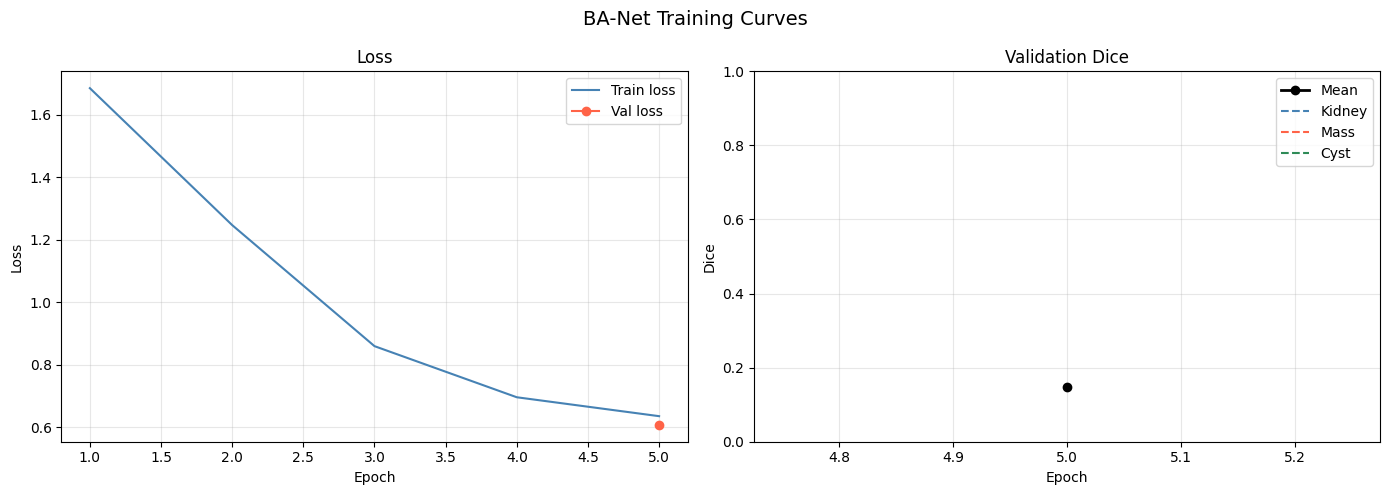

In [20]:
import matplotlib.pyplot as plt

with open(os.path.join(CFG["output_dir"], "history.json")) as f:
    history = json.load(f)

train_epochs = [r["epoch"] for r in history]
train_losses = [r["train_loss"] for r in history]

val_rows   = [r for r in history if "val_dice_mean" in r]
val_epochs = [r["epoch"] for r in val_rows]
val_losses = [r["val_val_loss"] for r in val_rows]
val_dice   = [r["val_dice_mean"] for r in val_rows]
val_dice_k = [r["val_dice_kidney"] for r in val_rows]
val_dice_m = [r["val_dice_mass"] for r in val_rows]
val_dice_c = [r["val_dice_cyst"] for r in val_rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 2 plot thay vi 3
fig.suptitle("BA-Net Training Curves", fontsize=14)

# Loss
axes[0].plot(train_epochs, train_losses, label="Train loss", color="steelblue")
axes[0].plot(val_epochs,   val_losses,   label="Val loss",   color="tomato", marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Dice
axes[1].plot(val_epochs, val_dice,   label="Mean",   color="black",     linewidth=2, marker="o")
axes[1].plot(val_epochs, val_dice_k, label="Kidney", color="steelblue", linestyle="--")
axes[1].plot(val_epochs, val_dice_m, label="Mass",   color="tomato",    linestyle="--")
axes[1].plot(val_epochs, val_dice_c, label="Cyst",   color="seagreen",  linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
axes[1].set_title("Validation Dice"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

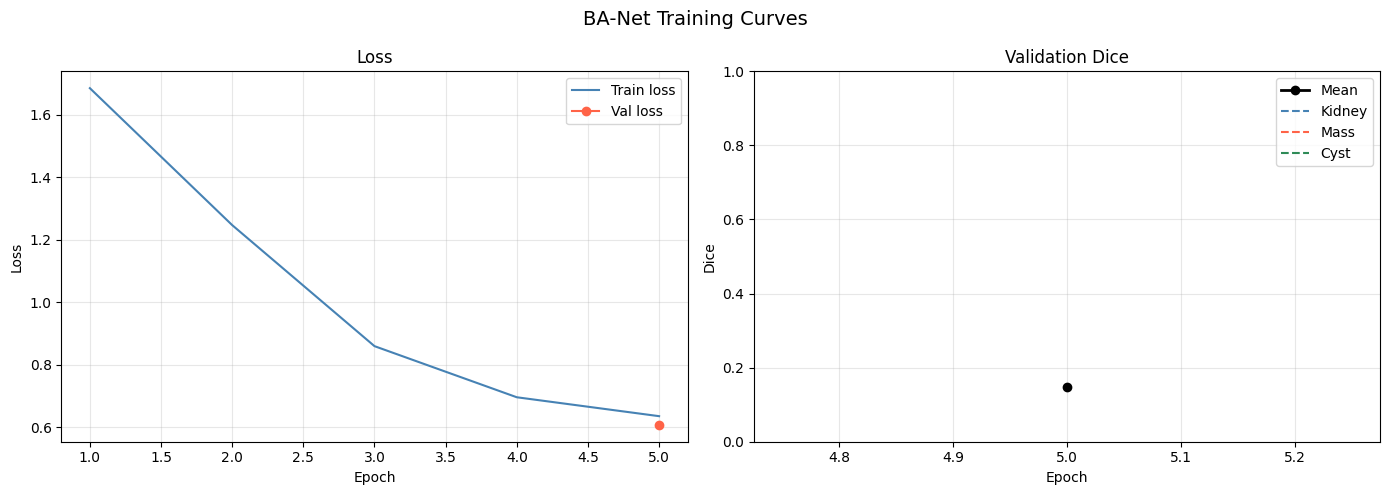

In [21]:
import matplotlib.pyplot as plt

with open(os.path.join(CFG["output_dir"], "history.json")) as f:
    history = json.load(f)

train_epochs = [r["epoch"] for r in history]
train_losses = [r["train_loss"] for r in history]

val_rows   = [r for r in history if "val_dice_mean" in r]
val_epochs = [r["epoch"] for r in val_rows]
val_losses = [r["val_val_loss"] for r in val_rows]
val_dice   = [r["val_dice_mean"] for r in val_rows]
val_dice_k = [r["val_dice_kidney"] for r in val_rows]
val_dice_m = [r["val_dice_mass"] for r in val_rows]
val_dice_c = [r["val_dice_cyst"] for r in val_rows]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BA-Net Training Curves", fontsize=14)

axes[0].plot(train_epochs, train_losses, label="Train loss", color="steelblue")
axes[0].plot(val_epochs,   val_losses,   label="Val loss",   color="tomato", marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(val_epochs, val_dice,   label="Mean",   color="black",     linewidth=2, marker="o")
axes[1].plot(val_epochs, val_dice_k, label="Kidney", color="steelblue", linestyle="--")
axes[1].plot(val_epochs, val_dice_m, label="Mass",   color="tomato",    linestyle="--")
axes[1].plot(val_epochs, val_dice_c, label="Cyst",   color="seagreen",  linestyle="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dice")
axes[1].set_title("Validation Dice"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

In [23]:
from monai.inferers import sliding_window_inference
from scipy.ndimage import binary_erosion, distance_transform_edt

def compute_hd95_scipy(pred_bin, gt_bin):
    # Squeeze het cac chieu thua, chi giu [D, H, W]
    pred_np = pred_bin.squeeze().cpu().numpy().astype(bool)
    gt_np   = gt_bin.squeeze().cpu().numpy().astype(bool)

    if pred_np.sum() == 0 or gt_np.sum() == 0:
        return float("nan")

    # struct phai co cung so chieu voi input
    struct = np.ones((3,) * pred_np.ndim, dtype=bool)

    edges_pred = pred_np ^ binary_erosion(pred_np, structure=struct)
    edges_gt   = gt_np   ^ binary_erosion(gt_np,   structure=struct)

    dist_gt2pred = distance_transform_edt(~edges_pred)
    dist_pred2gt = distance_transform_edt(~edges_gt)

    d1 = dist_gt2pred[edges_gt]
    d2 = dist_pred2gt[edges_pred]

    if len(d1) == 0 or len(d2) == 0:
        return float("nan")

    return float(np.percentile(np.concatenate([d1, d2]), 95))


# ---- Load best checkpoint ----
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} "
      f"(best Dice: {checkpoint['best_metric']:.4f})")


@torch.no_grad()
def evaluate_test_set(model, test_files, device, num_classes, patch_size, overlap=0.5):
    all_results = []

    for entry in test_files:
        case_id = os.path.splitext(os.path.basename(entry["image"]))[0]

        img = torch.load(entry["image"], weights_only=False).float().unsqueeze(0).to(device)
        lbl = torch.load(entry["label"], weights_only=False).long().unsqueeze(0).to(device)

        def predict_fn(x):
            seg, _ = model(x)
            return seg

        with torch.amp.autocast("cuda", enabled=CFG["use_amp"]):
            seg_logits = sliding_window_inference(
                img,
                roi_size=patch_size,
                sw_batch_size=2,
                predictor=predict_fn,
                overlap=overlap,
                mode="gaussian",
            )

        # Dice + IoU qua MONAI
        compute_metrics_batch(seg_logits, lbl, num_classes)
        case_metrics = aggregate_metrics(num_classes)

        # HD95 qua scipy
        pred_hard = seg_logits.argmax(dim=1, keepdim=True)  # [1,1,D,H,W]
        class_names = ["kidney", "mass", "cyst"]
        hd95_list = []
        for i, name in enumerate(class_names):
            c = i + 1  # bo background (class 0)
            hd = compute_hd95_scipy(pred_hard == c, lbl == c)
            case_metrics[f"hd95_{name}"] = hd
            hd95_list.append(hd)
        case_metrics["hd95_mean"] = float(np.nanmean(hd95_list))

        case_metrics["case_id"] = case_id
        all_results.append(case_metrics)

        print(
            f"{case_id} | "
            f"Dice: kidney={case_metrics['dice_kidney']:.3f} "
            f"mass={case_metrics['dice_mass']:.3f} "
            f"cyst={case_metrics['dice_cyst']:.3f} "
            f"mean={case_metrics['dice_mean']:.3f} | "
            f"HD95: kidney={case_metrics['hd95_kidney']:.1f} "
            f"mass={case_metrics['hd95_mass']:.1f} "
            f"cyst={case_metrics['hd95_cyst']:.1f} "
            f"mean={case_metrics['hd95_mean']:.1f}mm"
        )

        del img, lbl, seg_logits, pred_hard
        gc.collect()
        torch.cuda.empty_cache()

    return all_results


test_results = evaluate_test_set(
    model,
    test_files,
    DEVICE,
    CFG["num_classes"],
    CFG["patch_size"],
    overlap=0.5,
)

Loaded checkpoint from epoch 5 (best Dice: 0.1476)
case_00066 | Dice: kidney=0.068 mass=0.002 cyst=0.000 mean=0.023 | HD95: kidney=134.0 mass=239.5 cyst=292.4 mean=222.0mm
case_00036 | Dice: kidney=0.155 mass=0.003 cyst=0.000 mean=0.053 | HD95: kidney=127.3 mass=207.3 cyst=nan mean=167.3mm
case_00022 | Dice: kidney=0.147 mass=0.001 cyst=0.000 mean=0.049 | HD95: kidney=91.1 mass=208.6 cyst=nan mean=149.8mm
case_00133 | Dice: kidney=0.089 mass=0.001 cyst=0.000 mean=0.030 | HD95: kidney=136.1 mass=222.2 cyst=nan mean=179.2mm
case_00105 | Dice: kidney=0.098 mass=0.000 cyst=0.000 mean=0.033 | HD95: kidney=126.0 mass=203.3 cyst=184.7 mean=171.3mm
case_00056 | Dice: kidney=0.110 mass=0.002 cyst=0.000 mean=0.037 | HD95: kidney=108.8 mass=177.7 cyst=nan mean=143.3mm
case_00098 | Dice: kidney=0.214 mass=0.002 cyst=0.000 mean=0.072 | HD95: kidney=82.1 mass=176.4 cyst=nan mean=129.3mm
case_00154 | Dice: kidney=0.156 mass=0.003 cyst=0.000 mean=0.053 | HD95: kidney=91.6 mass=176.2 cyst=121.3 mean=12


=== Test Set Results ===
      dice_kidney  dice_mass  dice_cyst  dice_mean  iou_kidney  iou_mass  iou_cyst  iou_mean  hd95_kidney  hd95_mass  hd95_cyst  hd95_mean
mean       0.1396     0.0025     0.0001     0.0474      0.0760    0.0012    0.0000    0.0257     108.4564   191.7858   177.4406   153.8670
std        0.0560     0.0022     0.0001     0.0185      0.0330    0.0011    0.0001    0.0109      25.8290    39.7180    56.5364    32.5439
min        0.0619     0.0000     0.0000     0.0222      0.0319    0.0000    0.0000    0.0114      62.0484    77.5268   106.3654   111.7097
max        0.2717     0.0083     0.0006     0.0915      0.1572    0.0042    0.0003    0.0528     166.0873   271.3499   292.3856   221.9723


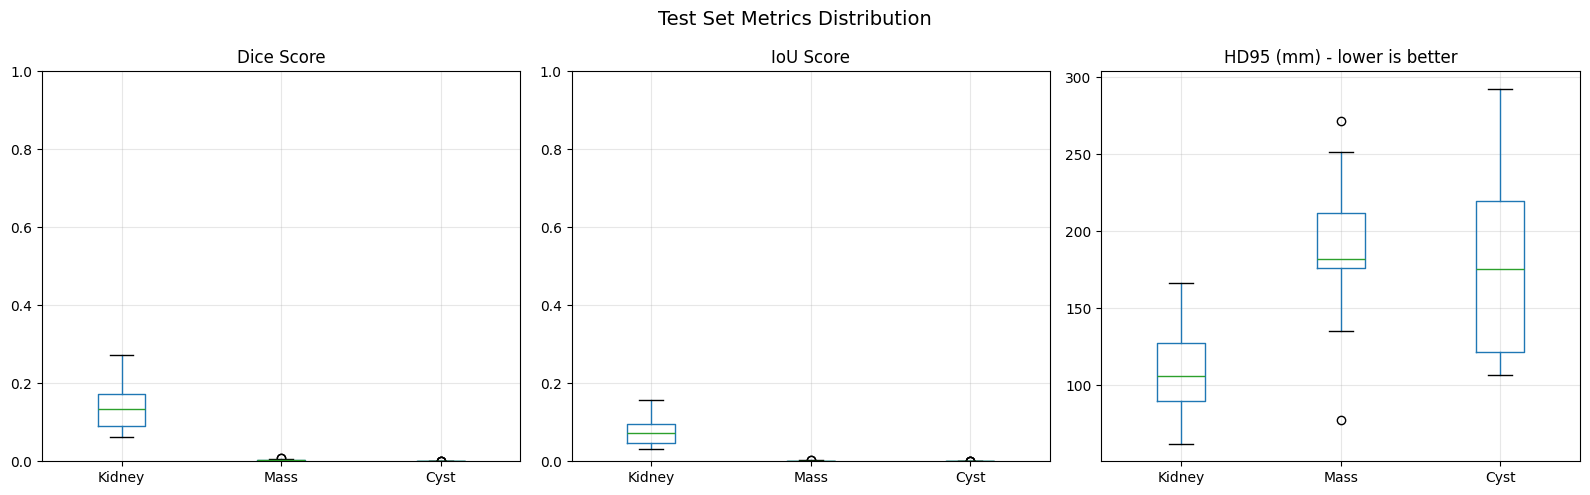

In [24]:
import pandas as pd

results_df = pd.DataFrame(test_results)
results_df = results_df.set_index("case_id")

# Aggregate summary row
summary = results_df.agg(["mean", "std", "min", "max"])

cols_of_interest = [
    "dice_kidney", "dice_mass", "dice_cyst", "dice_mean",
    "iou_kidney",  "iou_mass",  "iou_cyst",  "iou_mean",
    "hd95_kidney", "hd95_mass", "hd95_cyst", "hd95_mean",
]
print("\n=== Test Set Results ===")
print(summary[cols_of_interest].round(4).to_string())

# Save
results_df.to_csv(os.path.join(CFG["output_dir"], "test_results_per_case.csv"))
summary.to_csv(os.path.join(CFG["output_dir"], "test_results_summary.csv"))

# Box plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test Set Metrics Distribution", fontsize=14)

dice_cols = ["dice_kidney", "dice_mass", "dice_cyst"]
iou_cols  = ["iou_kidney",  "iou_mass",  "iou_cyst"]
hd95_cols = ["hd95_kidney", "hd95_mass", "hd95_cyst"]

results_df[dice_cols].boxplot(ax=axes[0])
axes[0].set_title("Dice Score")
axes[0].set_xticklabels(["Kidney", "Mass", "Cyst"], rotation=0)
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)

results_df[iou_cols].boxplot(ax=axes[1])
axes[1].set_title("IoU Score")
axes[1].set_xticklabels(["Kidney", "Mass", "Cyst"], rotation=0)
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

results_df[hd95_cols].boxplot(ax=axes[2])
axes[2].set_title("HD95 (mm) - lower is better")
axes[2].set_xticklabels(["Kidney", "Mass", "Cyst"], rotation=0)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CFG["output_dir"], "test_metrics_boxplot.png"), dpi=150, bbox_inches="tight")
plt.show()

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


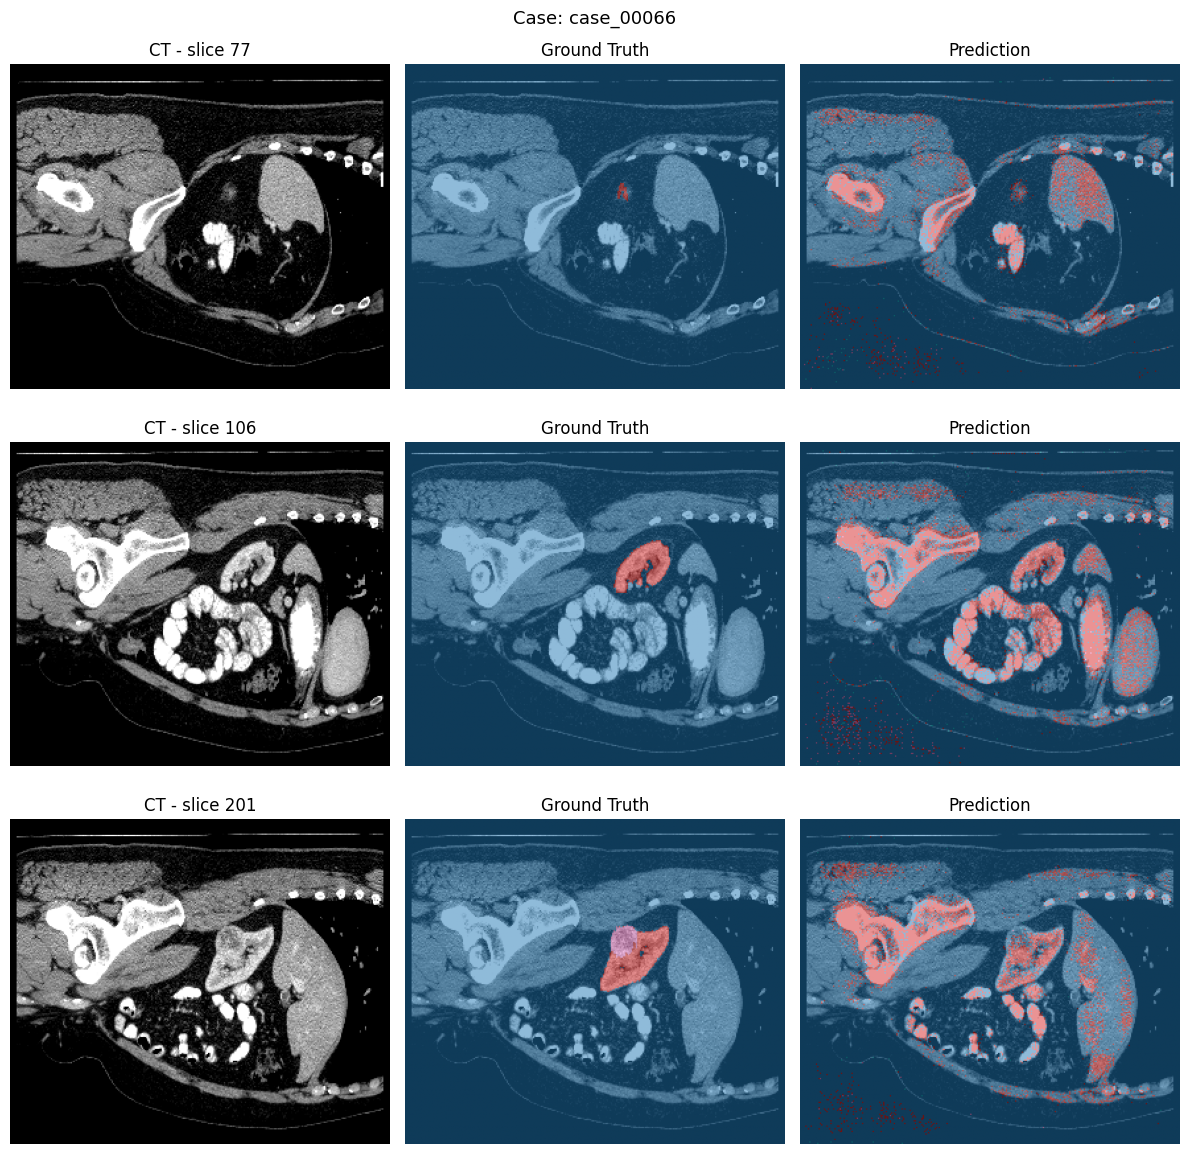

Saved to /kaggle/working/banet_output/viz_case_00066.png


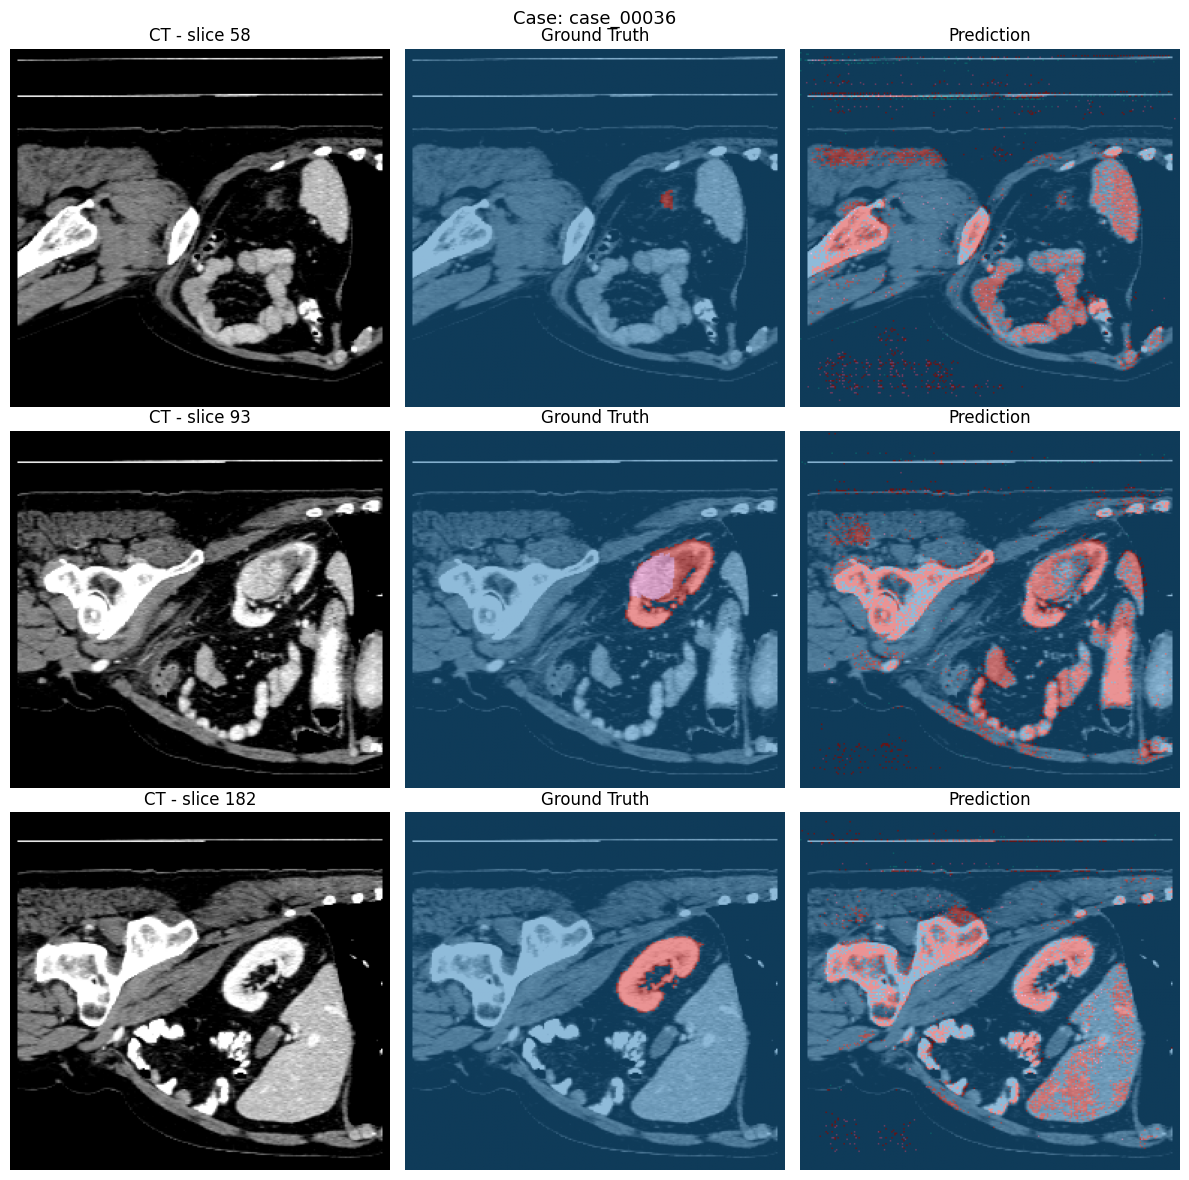

Saved to /kaggle/working/banet_output/viz_case_00036.png


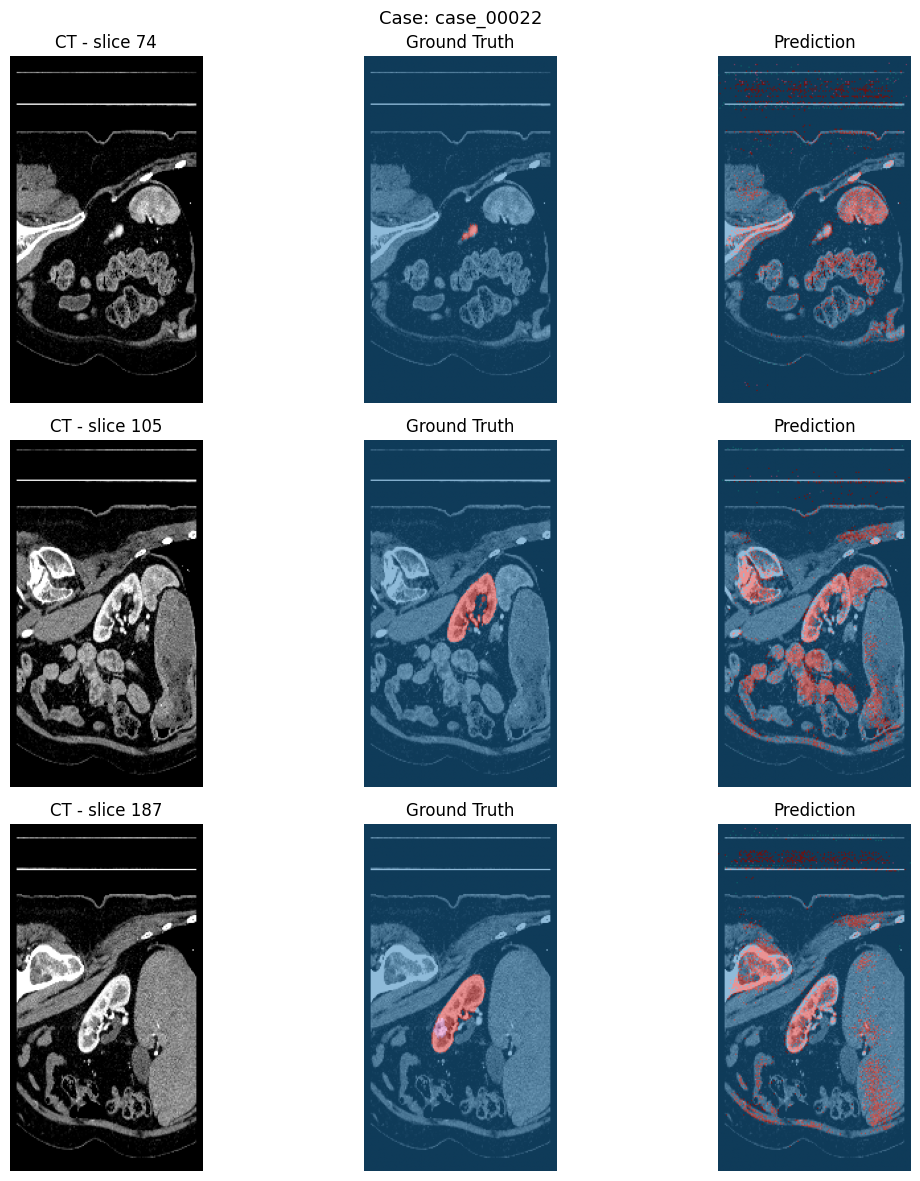

Saved to /kaggle/working/banet_output/viz_case_00022.png


In [26]:
@torch.no_grad()
def visualize_case(model, entry, device, patch_size, case_idx=0, num_slices=3):
    """
    Runs sliding-window inference on one case and displays
    num_slices axial slices comparing CT, Ground Truth, and Prediction.
    """
    case_id = os.path.splitext(os.path.basename(entry["image"]))[0]
    img = torch.load(entry["image"], weights_only=False).float().unsqueeze(0).to(device)
    lbl = torch.load(entry["label"], weights_only=False).long()

    def predict_fn(x):
        seg, _ = model(x)
        return seg

    with torch.amp.autocast("cuda", enabled=CFG["use_amp"]):
        seg_logits = sliding_window_inference(
            img, roi_size=patch_size, sw_batch_size=2,
            predictor=predict_fn, overlap=0.5, mode="gaussian"
        )

    pred = seg_logits.argmax(dim=1, keepdim=True).cpu().squeeze()  # [D, H, W]
    img_np = img.cpu().squeeze().numpy()
    lbl_np = lbl.squeeze().numpy()

    # Choose slices that contain foreground
    fg_slices = np.where(lbl_np.sum(axis=(1, 2)) > 50)[0]
    if len(fg_slices) < num_slices:
        slice_indices = np.linspace(0, lbl_np.shape[0] - 1, num_slices, dtype=int)
    else:
        step = len(fg_slices) // num_slices
        slice_indices = fg_slices[::step][:num_slices]

    cmap_label = plt.cm.get_cmap("tab10", 4)
    fig, axes = plt.subplots(num_slices, 3, figsize=(12, 4 * num_slices))
    fig.suptitle(f"Case: {case_id}", fontsize=13)

    for row, s in enumerate(slice_indices):
        axes[row, 0].imshow(img_np[s], cmap="gray")
        axes[row, 0].set_title(f"CT - slice {s}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_np[s], cmap="gray")
        axes[row, 1].imshow(lbl_np[s], cmap=cmap_label, alpha=0.5, vmin=0, vmax=3)
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(img_np[s], cmap="gray")
        axes[row, 2].imshow(pred.numpy()[s], cmap=cmap_label, alpha=0.5, vmin=0, vmax=3)
        axes[row, 2].set_title("Prediction")
        axes[row, 2].axis("off")

    plt.tight_layout()
    save_path = os.path.join(CFG["output_dir"], f"viz_{case_id}.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved to {save_path}")

    del img, seg_logits
    gc.collect(); torch.cuda.empty_cache()


# Visualize first 3 test cases
for entry in test_files[:3]:
    visualize_case(model, entry, DEVICE, CFG["patch_size"])

In [30]:
import nibabel as nib

EXPORT_DIR = os.path.join(CFG["output_dir"], "nifti_predictions")
os.makedirs(EXPORT_DIR, exist_ok=True)


@torch.no_grad()
def export_prediction_nifti(model, entry, device, patch_size):
    case_id = os.path.splitext(os.path.basename(entry["image"]))[0]
    img = torch.load(entry["image"], weights_only=False).float().unsqueeze(0).to(device)

    def predict_fn(x):
        seg, _ = model(x)
        return seg

    with torch.amp.autocast("cuda", enabled=CFG["use_amp"]):
        seg_logits = sliding_window_inference(
            img, roi_size=patch_size, sw_batch_size=2,
            predictor=predict_fn, overlap=0.5, mode="gaussian"
        )

    pred = seg_logits.argmax(dim=1).squeeze().cpu().numpy().astype(np.uint8)  # [D, H, W]

    # Save as NIfTI with identity affine (spacing info lost after .pt conversion;
    # load original NIfTI affine if you need physically correct spacing).
    nii = nib.Nifti1Image(pred, affine=np.eye(4))
    out_path = os.path.join(EXPORT_DIR, f"{case_id}_pred.nii.gz")
    nib.save(nii, out_path)
    print(f"Exported: {out_path}")

    del img, seg_logits
    gc.collect(); torch.cuda.empty_cache()


# Export all test cases
for entry in test_files[:5]:
    export_prediction_nifti(model, entry, DEVICE, CFG["patch_size"])

print(f"All predictions saved to {EXPORT_DIR}")

Exported: /kaggle/working/banet_output/nifti_predictions/case_00066_pred.nii.gz
Exported: /kaggle/working/banet_output/nifti_predictions/case_00036_pred.nii.gz
Exported: /kaggle/working/banet_output/nifti_predictions/case_00022_pred.nii.gz
Exported: /kaggle/working/banet_output/nifti_predictions/case_00133_pred.nii.gz
Exported: /kaggle/working/banet_output/nifti_predictions/case_00105_pred.nii.gz
All predictions saved to /kaggle/working/banet_output/nifti_predictions


In [31]:
import shutil

# Kiem tra output ton tai
output_files = [
    os.path.join(CFG["output_dir"], "checkpoints", "best_model.pth"),
    os.path.join(CFG["output_dir"], "history.json"),
    os.path.join(CFG["output_dir"], "test_results_summary.csv"),
    os.path.join(CFG["output_dir"], "training_curves.png"),
    os.path.join(CFG["output_dir"], "test_metrics_boxplot.png"),
]

for f in output_files:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1e6 if exists else 0
    print(f"{'OK' if exists else 'MISSING'} | {size:.1f}MB | {f}")

OK | 74.7MB | /kaggle/working/banet_output/checkpoints/best_model.pth
OK | 0.0MB | /kaggle/working/banet_output/history.json
OK | 0.0MB | /kaggle/working/banet_output/test_results_summary.csv
OK | 0.1MB | /kaggle/working/banet_output/training_curves.png
OK | 0.1MB | /kaggle/working/banet_output/test_metrics_boxplot.png
